# Fantasy Worlds ML Prediction App - Game of Thrones

## EDA, cleaning, feature engineering, model training, and evaluation

This notebook keeps Game of Thrones separate from the other universes. It avoids identifier, derived-prediction, relationship, and death-date columns that could leak target information.

Raw shape: (1946, 33)

Column types:
S.No                   int64
actual                 int64
pred                   int64
alive                float64
plod                 float64
name                     str
title                    str
male                   int64
culture                  str
dateOfBirth          float64
DateoFdeath          float64
mother                   str
father                   str
heir                     str
house                    str
spouse                   str
book1                  int64
book2                  int64
book3                  int64
book4                  int64
book5                  int64
isAliveMother        float64
isAliveFather        float64
isAliveHeir          float64
isAliveSpouse        float64
isMarried              int64
isNoble                int64
age                  float64
numDeadRelations       int64
boolDeadRelations      int64
isPopular              int64
popularity           float64
isAlive                int64
dtype:

Raw shape: (1946, 33)

Column types:
S.No                   int64
actual                 int64
pred                   int64
alive                float64
plod                 float64
name                     str
title                    str
male                   int64
culture                  str
dateOfBirth          float64
DateoFdeath          float64
mother                   str
father                   str
heir                     str
house                    str
spouse                   str
book1                  int64
book2                  int64
book3                  int64
book4                  int64
book5                  int64
isAliveMother        float64
isAliveFather        float64
isAliveHeir          float64
isAliveSpouse        float64
isMarried              int64
isNoble                int64
age                  float64
numDeadRelations       int64
boolDeadRelations      int64
isPopular              int64
popularity           float64
isAlive                int64
dtype:

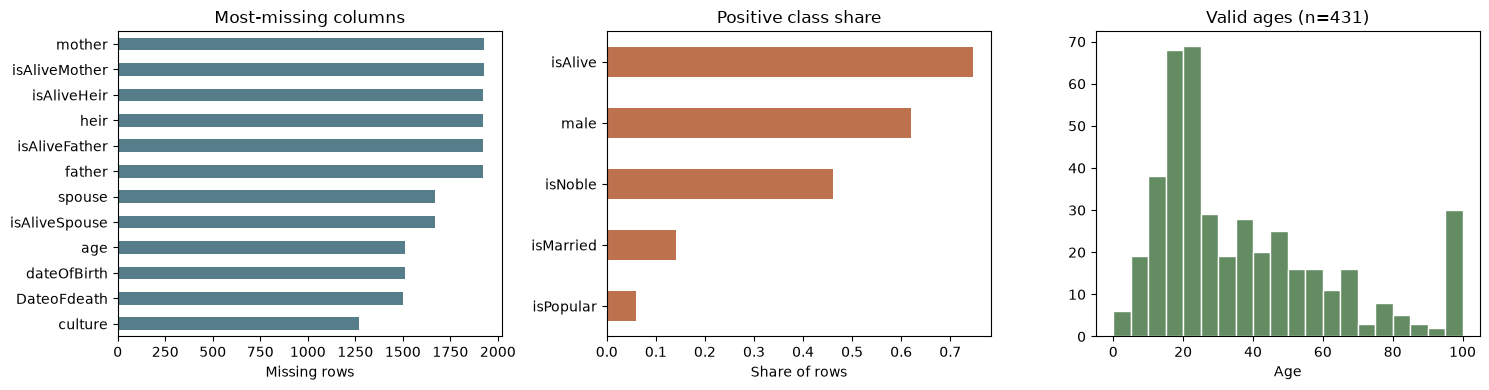

In [3]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
base_dirs = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next((d for d in base_dirs if (d / 'data').exists() and (d / 'models').exists()), Path.cwd())
DATA_DIR = PROJECT_DIR / 'data'
MODEL_DIR = PROJECT_DIR / 'models'
DATA_PATH = DATA_DIR / 'got.csv'
CLEAN_PATH = DATA_DIR / 'got_characters_clean.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
print('\nColumn types:')
print(df_raw.dtypes)
print('\nMissing values (largest first):')
print(df_raw.isna().sum().sort_values(ascending=False).head(15))

candidate_targets = ['isAlive', 'male', 'isNoble', 'isMarried', 'isPopular', 'popularity', 'age']
print('\nCandidate target summary:')
for target in candidate_targets:
    values = df_raw[target].dropna()
    print(f'\n{target}: non-missing={len(values)}, unique={values.nunique()}')
    print(values.value_counts().head(10) if values.nunique() <= 20 else values.describe())

## Cleaning and feature engineering

The raw file contains derived columns (`actual`, `pred`, `alive`, `plod`), identifiers, relationship names, and date fields. These are excluded from the modeling table to reduce leakage and high-cardinality noise.

In [5]:
numeric_features = [
    'book1', 'book2', 'book3', 'book4', 'book5',
    'numDeadRelations', 'boolDeadRelations'
]
categorical_features = ['culture', 'house', 'title']
feature_columns = numeric_features + categorical_features
target_columns = ['isAlive', 'male', 'isNoble', 'isMarried', 'isPopular', 'popularity', 'age']

df = df_raw.copy()
for column in categorical_features:
    df[column] = df[column].fillna('Unknown').astype(str).str.strip()
    counts = df[column].value_counts()
    rare_values = counts[counts < 5].index
    df[column] = df[column].where(~df[column].isin(rare_values), 'Other')

df_clean = df[feature_columns + target_columns].copy()
df_clean.to_csv(CLEAN_PATH, index=False)
print(f'Clean modeling table shape: {df_clean.shape}')
print(f'Saved cleaned data to {CLEAN_PATH}')

Clean modeling table shape: (1946, 17)
Saved cleaned GoT data to c:\Users\hp\Downloads\fantasy-ml-project\fantasy-ml-project\data\got_characters_clean.csv

Target rows available:
isAlive       1946
male          1946
isNoble       1946
isMarried     1946
isPopular     1946
culture       1946
house         1946
title         1946
popularity    1946
age            431
dtype: int64

Classification class counts:

isAlive:
isAlive
1    1451
0     495
Name: count, dtype: int64

male:
male
1    1205
0     741
Name: count, dtype: int64

isNoble:
isNoble
0    1049
1     897
Name: count, dtype: int64

isMarried:
isMarried
0    1670
1     276
Name: count, dtype: int64

isPopular:
isPopular
0    1831
1     115
Name: count, dtype: int64

culture:
culture
Unknown                    1269
Northmen                    124
Ironborn                    112
Other                        73
Free Folk                    51
Valyrian                     43
Braavosi                     42
Dornish                 

## Modeling helpers

Each target gets its own train/test split and pipeline. Categorical values are one-hot encoded with unknown-value handling, while numeric values use median imputation.

In [10]:
def make_preprocessor():
    numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('numeric', numeric_pipe, numeric_features),
        ('categorical', categorical_pipe, categorical_features)
    ])

def make_classification_pipeline(model):
    return Pipeline([('preprocessor', make_preprocessor()), ('model', model)])

def make_regression_pipeline(model):
    return Pipeline([('preprocessor', make_preprocessor()), ('model', model)])

def train_classification_target(target):
    data = df_clean.dropna(subset=[target])
    X = data[feature_columns]
    y = data[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    candidates = {
        'logistic_regression': make_classification_pipeline(LogisticRegression(max_iter=2000, class_weight='balanced')),
        'random_forest': make_classification_pipeline(RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1))
    }
    results = []
    for name, pipeline in candidates.items():
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        results.append({
            'model_name': name,
            'pipeline': pipeline,
            'accuracy': float(accuracy_score(y_test, predictions)),
            'balanced_accuracy': float(balanced_accuracy_score(y_test, predictions)),
            'f1_macro': float(f1_score(y_test, predictions, average='macro'))
        })
    winner = max(results, key=lambda result: result['balanced_accuracy'])
    return winner, len(data), sorted(data[target].astype(int).unique().tolist())

def train_regression_target(target):
    data = df_clean.dropna(subset=[target])
    X = data[feature_columns]
    y = data[target].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    candidates = {
        'ridge': make_regression_pipeline(Ridge(alpha=1.0)),
        'random_forest': make_regression_pipeline(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    }
    results = []
    for name, pipeline in candidates.items():
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        results.append({
            'model_name': name,
            'pipeline': pipeline,
            'mae': float(mean_absolute_error(y_test, predictions)),
            'rmse': float(np.sqrt(mean_squared_error(y_test, predictions))),
            'r2': float(r2_score(y_test, predictions))
        })
    winner = min(results, key=lambda result: result['rmse'])
    return winner, len(data), None

In [11]:
manifest = {
    'universe': 'got',
    'n_rows': int(len(df_clean)),
    'id_column': 'name',
    'feature_columns': feature_columns,
    'targets': {}
}
classification_targets = ['isAlive', 'male', 'isNoble', 'isMarried', 'isPopular']
regression_targets = ['popularity', 'age']

for target in classification_targets:
    winner, n_rows, classes = train_classification_target(target)
    model_file = f'got_{target}.pkl'
    joblib.dump(winner['pipeline'], MODEL_DIR / model_file)
    manifest['targets'][target] = {
        'task': 'classification',
        'model_file': model_file,
        'model_name': winner['model_name'],
        'feature_columns': feature_columns,
        'classes': [str(value) for value in classes],
        'n_rows': n_rows,
        'metrics': {key: value for key, value in winner.items() if key in ['accuracy', 'balanced_accuracy', 'f1_macro']}
    }
    print(target, manifest['targets'][target]['metrics'])

for target in regression_targets:
    winner, n_rows, _ = train_regression_target(target)
    model_file = f'got_{target}.pkl'
    joblib.dump(winner['pipeline'], MODEL_DIR / model_file)
    manifest['targets'][target] = {
        'task': 'regression',
        'model_file': model_file,
        'model_name': winner['model_name'],
        'feature_columns': feature_columns,
        'n_rows': n_rows,
        'metrics': {key: value for key, value in winner.items() if key in ['mae', 'rmse', 'r2']}
    }
    print(target, manifest['targets'][target]['metrics'])

manifest_path = MODEL_DIR / 'got_manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print(f'Saved manifest to {manifest_path}')

isAlive: RandomForestClassifier; {'accuracy': 0.6666666666666666, 'balanced_accuracy': 0.6633343746745808, 'f1_macro': 0.625}; inputs=10
male: RandomForestClassifier; {'accuracy': 0.6410256410256411, 'balanced_accuracy': 0.6480548052020385, 'f1_macro': 0.6355042858287271}; inputs=10
isNoble: RandomForestClassifier; {'accuracy': 0.7410256410256411, 'balanced_accuracy': 0.7424603174603175, 'f1_macro': 0.740641975308642}; inputs=9
isMarried: DecisionTreeClassifier; {'accuracy': 0.6666666666666666, 'balanced_accuracy': 0.6995929443690638, 'f1_macro': 0.5789596066967845}; inputs=10
isPopular: RandomForestClassifier; {'accuracy': 0.8846153846153846, 'balanced_accuracy': 0.8368084350195475, 'f1_macro': 0.6900333810205055}; inputs=10
culture: RandomForestClassifier; {'accuracy': 0.28974358974358977, 'balanced_accuracy': 0.5209784016128419, 'f1_macro': 0.26398976501081767}; inputs=9
house: LogisticRegression; {'accuracy': 0.1641025641025641, 'balanced_accuracy': 0.2448747871694589, 'f1_macro': 

In [12]:
print('Smoke test')
for target, metadata in manifest['targets'].items():
    model = joblib.load(MODEL_DIR / metadata['model_file'])
    sample = df_clean[metadata['feature_columns']].iloc[[0]]
    prediction = model.predict(sample)[0]
    print(f'{target}: {prediction}')
print('GoT pipeline complete.')

Smoke test
isAlive: 0
male: 1
isNoble: 0
isMarried: 0
isPopular: 1
culture: Valyrian
house: House Blackfyre
title: Unknown
popularity: 0.7116436184278987
age: 30.34125387210232
GoT pipeline complete.
